## Not using deep learning algorithm but identify the lane marking by looking at the intensity value

In [153]:
import numpy as np
import pandas as pd
import geopandas as gp
import matplotlib.pyplot as plt

from shapely import wkt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist
from scipy.spatial.distance import squareform

import utm



+ The intensity of each LIDAR point should contain enough information to recover the lane marking from the flat surface since the lane marking should have a higher intensity compared to the plain asphalt or concrete of the street. 

In [154]:
data=[]
with open('./output_data_0(0052).txt') as f:
    line = f.readline()
    while line:
        d=line.split()
        tmp=[]
        for i in d:
            tmp.append(float(i)) # convert string to float
        data.append(tmp)
        line=f.readline()

In [155]:
a=np.array(data)

### assumption: There's no void space line in txt file.
### intensity: 0~255
pointcloud_df = pd.DataFrame()
pointcloud_df["Latitude"] = a[:,0]
pointcloud_df["Longitude"] = a[:,1]
pointcloud_df["Altitude"] = a[:,2]
i = a[:,3]*255
ii=[]
for x in i:
    ii.append(int(x))
pointcloud_df["Intensity"] = ii

In [156]:
pointcloud_df

,Latitude,Longitude,Altitude,Intensity
0,34.808998,5.520,1.401,0
1,34.828999,5.636,1.402,0
2,34.806000,5.688,1.402,0
3,34.534000,5.755,1.393,0
4,34.563000,5.871,1.395,0
...,...,...,...,...
114273,3.679000,-1.417,-1.722,68
114274,3.688000,-1.408,-1.725,73
114275,3.669000,-1.387,-1.713,63
114276,3.692000,-1.383,-1.722,33


In [157]:
def convert_fuse(pointcloud_df, min_x = 0.0, min_y = 0.0, min_z = 0.0):
    pointcloud_df["Latitude"] = pd.to_numeric(pointcloud_df["Latitude"])
    pointcloud_df["Longitude"] = pd.to_numeric(pointcloud_df["Longitude"])
    pointcloud_df["Altitude"] = pd.to_numeric(pointcloud_df["Altitude"])
    pointcloud_df["Intensity"] = pd.to_numeric(pointcloud_df["Intensity"])
    
    #Coordinate Conversions
#    pointcloud_df["Easting"] = pointcloud_df.apply(lambda x: utm.from_latlon(x["Latitude"], x["Longitude"])[0], axis = 1)
#    pointcloud_df["Northing"] = pointcloud_df.apply(lambda x: utm.from_latlon(x["Latitude"], x["Longitude"])[1], axis = 1)
 
    pointcloud_df["Easting"] = pointcloud_df.apply(lambda x: x["Latitude"]*np.cos(x["Longitude"]), axis = 1)
    pointcloud_df["Northing"] = pointcloud_df.apply(lambda x: x["Latitude"]*np.sin(x["Longitude"]), axis = 1)


    if min_x == 0:
        min_x = pointcloud_df["Easting"].min()
    if min_y == 0:
        min_y = pointcloud_df["Northing"].min()   
    if min_z == 0:
        min_z = pointcloud_df["Altitude"].min()    
        
    utm_coords = utm.from_latlon(pointcloud_df.loc[0,"Latitude"], pointcloud_df.loc[0,"Longitude"])

    zone_number = utm_coords[2]
    zone_letter = utm_coords[3]
        
    # negative to positive ? maybe
    pointcloud_df["Easting"] = pointcloud_df["Easting"] - min_x    
    pointcloud_df["Northing"] = pointcloud_df["Northing"] - min_y
    pointcloud_df["Altitude"] = pointcloud_df["Altitude"] - min_z
    
    return pointcloud_df, (min_x, min_y, min_z), (zone_number, zone_letter)

In [158]:
pointcloud_df, (min_x, min_y, min_z), (number, letter) = convert_fuse(pointcloud_df)

In [159]:
pointcloud_df.head()

,Latitude,Longitude,Altitude,Intensity,Easting,Northing
0,34.808998,5.520,20.645000,0,103.531258,51.684665
1,34.828999,5.636,20.645999,0,106.162980,54.745670
2,34.806000,5.688,20.645999,0,107.197882,56.231174
3,34.534000,5.755,20.636999,0,108.204771,58.341591
4,34.563000,5.871,20.638999,0,110.045218,61.899199


In [160]:
xyzi_df = pointcloud_df[["Easting", "Northing", "Altitude", "Intensity"]]
xyzi_df.to_csv("./pointcloud.xyz", sep=" ", header=False, index=False)
xyzi_df.head()

,Easting,Northing,Altitude,Intensity
0,103.531258,51.684665,20.645000,0
1,106.162980,54.745670,20.645999,0
2,107.197882,56.231174,20.645999,0
3,108.204771,58.341591,20.636999,0
4,110.045218,61.899199,20.638999,0


## 2. Pointcloud Filtering

1. remove noise (too high or too low intensity)
2. set an adaptive threshold. (lane marking points have a higher intensity value)

In [161]:
def convert_to_shape(row):
    return wkt.loads("POINT (" + str(row["Easting"]) + " " + str(row["Northing"]) +" " + str(row["Altitude"]) + ")")

In [162]:
def filter_by_mean_value(pointcloud_df):

    mean = pointcloud_df["Intensity"].mean()
    std = pointcloud_df["Intensity"].std()

    lanes_df = pointcloud_df[pointcloud_df["Intensity"] > mean + 1 * std]
    lanes_df = lanes_df[lanes_df["Intensity"] < mean + 7 * std ]
    
    print("MEAN FILTER:")
    print("============")
    print("Intensity - Mean value:      ", mean)
    print("Intensity - Std value:       ", std)
    print("Intensity - Lower bound:     ", mean + 1 * std)
    print("Intensity - Upper bound:     ", mean + 9 * std)
    print("Intensity - Filtered points: ", len(lanes_df))
    print("Intensity - Original points: ", len(pointcloud_df))
    print("Intensity - Reduction to %:  ", len(lanes_df)/len(pointcloud_df))
    
    return lanes_df

In [163]:
lanes_df = xyzi_df.copy()
lanes_df = filter_by_mean_value(lanes_df)
lanes_df[['Easting', 'Northing', 'Altitude', 'Intensity']].to_csv("./filter_mean.xyz", index=False)

MEAN FILTER:
Intensity - Mean value:       47.7233850784928
Intensity - Std value:        41.03483419295528
Intensity - Lower bound:      88.75821927144807
Intensity - Upper bound:      417.0368928150903
Intensity - Filtered points:  18664
Intensity - Original points:  114278
Intensity - Reduction to %:   0.1633210241691314


## 3. Lane Marking Detection

In [164]:
X = lanes_df[["Easting", "Northing", "Altitude"]].values
X = StandardScaler().fit_transform(X)

In [195]:
db = DBSCAN(eps=0.5, min_samples=30).fit(X)
#eps: The maximum distance between two samples for one to be considered as in the neighborhood of the other. (default=0.5)
#min_samplesint: The number of samples (or total weight) in a neighborhood for a point to be considered as a core point.(default=5)

labels = db.labels_
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

In [196]:
lanes_df["Group"] = labels
cluster_df = lanes_df[["Easting", "Northing", "Altitude", "Group"]]
cluster_df = cluster_df[cluster_df["Group"]>=0]
cluster_df.to_csv("./clustering.xyz",index=False)
cluster_df.head()

,Easting,Northing,Altitude,Group
145,76.566073,76.495443,19.566999,0
148,76.597301,76.484598,19.566999,0
151,76.634770,76.473127,19.565999,0
153,76.657839,76.463493,19.564999,0
160,76.746666,76.447557,19.562999,0


In [197]:
print("Final list of labels:       ", labels)
print("Number of Clusters:         ", n_clusters_)
print("Number of Noise points:     ", n_noise_)
print("Number of clustered points: ", len(cluster_df))

Final list of labels:        [-1 -1 -1 ...  0  0  0]
Number of Clusters:          3
Number of Noise points:      1139
Number of clustered points:  17525


In [198]:
print(lanes_df["Easting"].max())
print(lanes_df["Easting"].min())
print(lanes_df["Easting"].mean())
print("---------------------------")
print(lanes_df["Northing"].max())
print(lanes_df["Northing"].min())
print(lanes_df["Northing"].mean())

141.10167813811827
8.322608857407943
78.04849894316206
---------------------------
137.3327518312469
10.352448567253788
75.24080860191559


In [199]:
lines = []

for cluster in range(n_clusters_):
    sub_cluster_df = cluster_df[cluster_df["Group"] == cluster]
    points = sub_cluster_df[["Easting","Northing", "Altitude"]].values
    distances = squareform(pdist(points))
    for i in range(0,15):
        max_index = np.argmax(distances)
        i1, i2 = np.unravel_index(max_index, distances.shape)
        distances[i1,i2] = 0.0
    max_dist = np.max(distances)
    max_index = np.argmax(distances)
    i1, i2 = np.unravel_index(max_index, distances.shape)
    p1 = sub_cluster_df.iloc[i1]
    p2 = sub_cluster_df.iloc[i2]
    lines.append(([p1["Easting"], p2["Easting"]],[p1["Northing"], p2["Northing"]], [p1["Altitude"], p2["Altitude"]]))

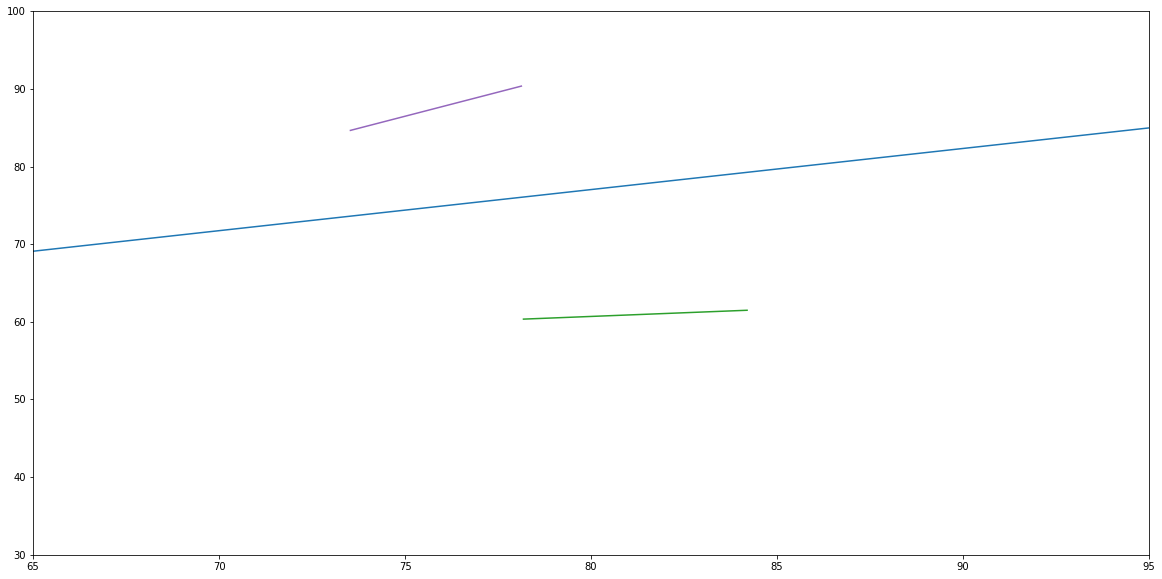

Number of prototype lane markings:  3


In [200]:
plt.figure(figsize=(20,10))
plt.xlim(65,95)
plt.ylim(30,100)

for l in lines:
    plt.plot(l[0], l[1], l[2])
    
plt.show()

print("Number of prototype lane markings: ", len(lines))

In [96]:
def create_line(coords):
    return wkt.loads("LINESTRING(" + str(coords[0][0]) + " " +str(coords[1][0]) + ", " + str(coords[0][1]) + " " + str(coords[1][1]) +")")
    
distance_matrix = []

for l1 in range(len(lines)):
    prototype = []
    distances = []
    line1 = create_line(lines[l1])
    for l2 in range(len(lines)):
        line2 = create_line(lines[l2])
        d = line1.distance(line2)
        if d == 0:
            d = 100
        distances.append(d)
        
    distance_matrix.append(distances)

distances = np.array(distance_matrix)

In [97]:
fusions = set()

for row in range(distances.shape[0]):
    for column in range(distances.shape[1]):
        value = distances[row,column]
        if value < 1.0:
            min_index = min(row, column)
            max_index = max(row, column)
            fusions.add((min_index, max_index))
            
fusions = list(fusions)
fusion_clusters = []
finished = []
fusions.sort()

for i in range(len(fusions)):
    new_cluster = list(fusions[i])
    if new_cluster[0] not in finished and new_cluster[1] not in finished:
        for j in range(i+1, len(fusions)):
            f = list(fusions[j])
            if (f[0] in new_cluster or f[1] in new_cluster) and f[0] not in finished:
                new_cluster.extend(f)
        fusion_clusters.append(list(set(new_cluster)))
        finished.extend(list(set(new_cluster)))
        
fused_lines = [item for sublist in fusion_clusters for item in sublist]
for i in range(distances.shape[0]):
    if i not in fused_lines:
        fusion_clusters.append([i])

In [98]:
final_lane_markings = []

for cluster in fusion_clusters:
    if len(cluster) == 1:
        final_lane_markings.append(lines[cluster[0]])
    else:
        points = []
        for segment in cluster:
            l = lines[segment]
            points.append([l[0][0], l[1][0], l[2][0]])
            points.append([l[0][1], l[1][1], l[2][1]])
        points = np.array(points)
        distances = squareform(pdist(points))
        max_dist = np.max(distances)
        max_index = np.argmax(distances)
        i1, i2 = np.unravel_index(max_index, distances.shape)
        
        p1 = points[i1]
        p2 = points[i2]

        final_lane_markings.append(([p1[0], p2[0]],[p1[1], p2[1]], [p1[2], p2[2]]))

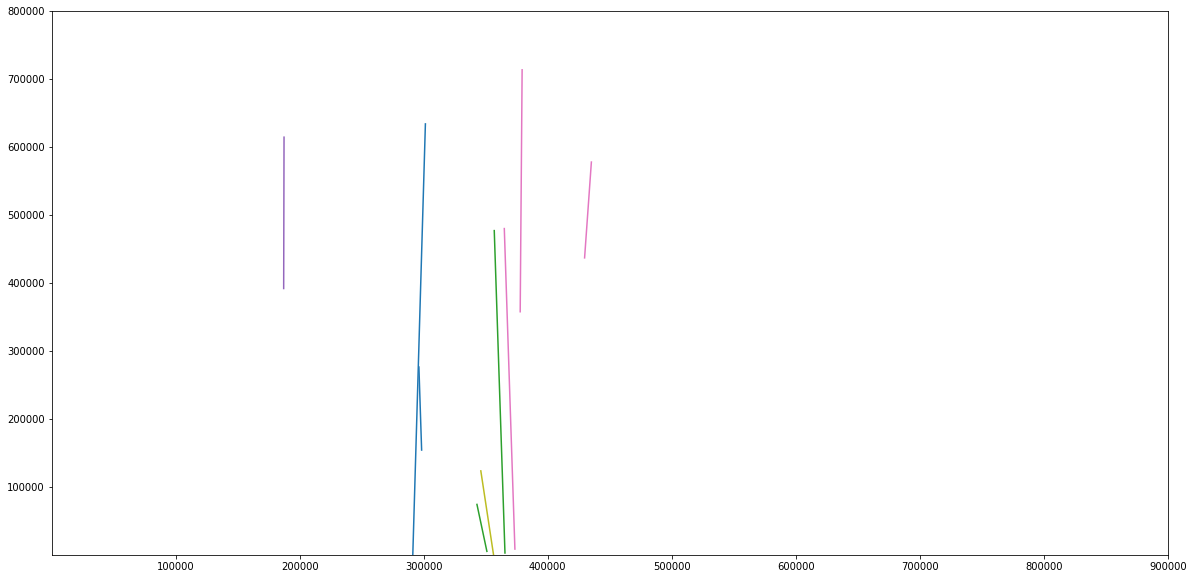

Number of final lane markings:  21


In [99]:
plt.figure(figsize=(20,10))
plt.xlim(100, 900000), plt.ylim(1000,800000) ## 
for l in final_lane_markings:
    plt.plot(l[0], l[1], l[2])
    
plt.show()

print("Number of final lane markings: ", len(final_lane_markings))